# Algoritma Machine Learning untuk Deteksi Spoiler pada Review Buku di Platform Goodreads (Di Run menggunakan VS Code)

Dataset ini digunakan untuk melatih dan mengevaluasi model Machine Learning dalam mendeteksi spoiler pada review buku Goodreads berbahasa Indonesia.

Input -> `review_preprocessed.csv` (hasil preprocessing)

Kolom yang dipakai -> `review_text_stem`, `spoiler_label`

Alur notebook:

Load data -> eksplorasi -> train-test split -> tuning SVM -> tuning random forest -> tuning xgboost -> perbandingan -> visualisasi paper

## 1. Instalasi Dependensi

Catatan perubahan: imbalanced-learn tidak dipakai karena smote tidak cocok untuk sparse matrix tfidf.
handling imbalance dilakukan via class_weight dan scale_pos_weight langsung di fungsi loss.

In [ ]:
# install semua library yang dibutuhkan
# scikit-learn: library utama ML, sudah include SVM, Random Forest, Pipeline, dan GridSearchCV
# xgboost: implementasi gradient boosting yang dioptimasi
# pandas, numpy: manipulasi data dan operasi numerik
# matplotlib, seaborn: visualisasi

!pip install scikit-learn xgboost pandas numpy matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import Library dan Konfigurasi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.feature_extraction.text import TfidfVectorizer # untuk mengubah teks menjadi angka
from sklearn.pipeline import Pipeline # untuk menggabungkan TF-IDF + model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold # untuk membagi data dan mencari hyperparameter terbaik

# import model-model machine learning yang akan digunakan
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,    # laporan lengkap precision, recall, f1 per kelas
    confusion_matrix,         # tabel perbandingan prediksi vs aktual
    roc_auc_score,            # skor AUC-ROC, metrik utama
    precision_score,          # dari semua yang diprediksi positif, berapa yang benar
    recall_score,             # dari semua yang benar positif, berapa yang berhasil terdeteksi
    f1_score,                 # rata-rata harmonis antara precision dan recall
    ConfusionMatrixDisplay    # untuk menampilkan confusion matrix dalam bentuk visual
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# path input
INPUT_CSV = '/content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv'
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# konstanta global
RANDOM_SEED = 42 # seed untuk reproducibility
TEST_SIZE = 0.2 # 80% train, 20% test

## 3. Load dan Eksplorasi Data

In [ ]:
# load data hasil preprocessing
# encoding='utf-8-sig' menangani karakter BOM yang kadang muncul di file Windows
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

# informasi dasar tentang dataset
print(f"total baris: {len(df)}")
print(f"total kolom: {len(df.columns)}")
print(f"kolom: {list(df.columns)}")

# cek missing value pada kolom yang akan dipakai
print("\nmissing values pada kolom yang dipakai")
print(df[["review_text_stem", "spoiler_label"]].isnull().sum())

# hapus baris yang kolom utamanya kosong
# reset_index(drop=True) biar index kembali rapi dari 0
df = df.dropna(subset=["review_text_stem", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah drop missing: {len(df)} baris")

total baris: 8694
total kolom: 3
kolom: ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values pada kolom yang dipakai
review_text_stem    0
spoiler_label       0
dtype: int64

setelah drop missing: 8694 baris


In [ ]:
# distribusi label dan perhitungan imbalance ratio (berapa review spoiler vs non-spoiler)
label_counts = df["spoiler_label"].value_counts()
label_pct = df["spoiler_label"].value_counts(normalize=True) * 100

print("distribusi label")
print()
# gabungkan jumlah dan persentase ke satu tabel yang mudah dibaca
dist_df = pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : label_pct.round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"})
print(dist_df)

# hitung imbalance ratio, seberapa jauh ketimpangan antara dua kelas
n_nonspoiler = label_counts[0]
n_spoiler = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler # angka ini nanti dipakai di XGBoost

print(f"\nimbalance ratio (non-spoiler / spoiler): {imbalance_ratio:.2f}")
print(f"untuk setiap 1 spoiler, ada {imbalance_ratio:.1f} non-spoiler")

distribusi label

                 jumlah  persen
spoiler_label                  
non-spoiler (0)    7943   91.36
spoiler (1)         751    8.64

imbalance ratio (non-spoiler / spoiler): 10.58
untuk setiap 1 spoiler, ada 10.6 non-spoiler


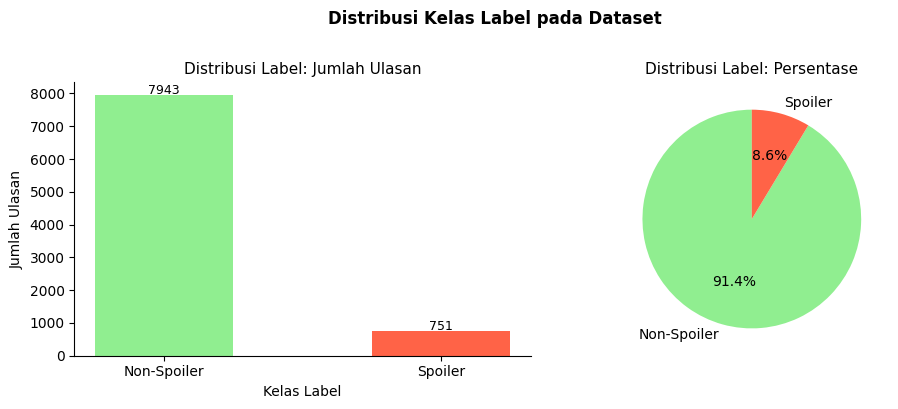

In [ ]:
# visualisasi distribusi label (bar chart dan pie chart)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

COLORS = ["lightgreen", "tomato"]

# bar chart
axes[0].bar(["Non-Spoiler", "Spoiler"], [n_nonspoiler, n_spoiler], color=COLORS, width=0.5)
axes[0].set_title("Distribusi Label: Jumlah Ulasan", fontsize=11)
axes[0].set_ylabel("Jumlah Ulasan")
axes[0].set_xlabel("Kelas Label")
axes[0].spines[["top","right"]].set_visible(False)
for i, v in enumerate([n_nonspoiler, n_spoiler]):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=9)

# pie chart
axes[1].pie(
    [n_nonspoiler, n_spoiler],
    labels=["Non-Spoiler", "Spoiler"],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    wedgeprops={"linewidth": 1.5}
)
axes[1].set_title("Distribusi Label: Persentase", fontsize=11)

plt.suptitle("Distribusi Kelas Label pada Dataset", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("distribusi_label.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# hitung panjang teks (dalam jumlah kata/token) per review
# panjang teks bisa jadi sinyal, spoiler mungkin cenderung lebih panjang
df["text_len"] = df["review_text_stem"].apply(lambda x: len(str(x).split()))

# tampilkan statistik deskriptif panjang teks, dikelompokkan berdasarkan label
print("statistik panjang teks (jumlah token) per label")
print()
print(df.groupby("spoiler_label")["text_len"].describe().round(2).rename(index={0: "non-spoiler", 1: "spoiler"}))

statistik panjang teks (jumlah token) per label

                count   mean    std  min   25%   50%    75%     max
spoiler_label                                                      
non-spoiler    7943.0  63.32  71.43  1.0  18.0  40.0   83.0  1149.0
spoiler         751.0  83.50  83.45  2.0  30.5  59.0  117.0   874.0


## 4. Persiapan Data & Train-Test Split

Catatan perubahan: tfidf tidak di-fit di sini. tfidf dimasukkan ke dalam pipeline bersama setiap algoritma supaya saat gridsearchcv berjalan, tfidf di-fit ulang hanya pada data training di setiap fold. jika tfidf di-fit di luar, vocabulary sudah terbentuk dari semua train data sebelum cross-validation dimulai (data leakage).

In [ ]:
# persiapan data
# X (fitur/input) dan y (label/target)
# .astype(str) memastikan tidak ada tipe data campuran yang bisa menyebabkan error
# X berisi raw text, bukan matriks TF-IDF
# TF-IDF sekarang ada di dalam Pipeline setiap model
X = df["review_text_stem"].astype(str).tolist()
y = df["spoiler_label"].astype(int)

print(f"jumlah sampel: {len(X)}")
print(f"distribusi y: {dict(y.value_counts().sort_index())}")

jumlah sampel: 8694
distribusi y: {0: np.int64(7943), 1: np.int64(751)}


In [ ]:
# split data: 80% train, 20% test
# stratify=y memastikan proporsi label sama di train dan test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

# split 15% dari train sebagai validation set untuk threshold tuning
# (konsisten dengan pendekatan BiLSTM dan IndoBERT)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_train
)

# hitung imbalance ratio untuk scale_pos_weight xgboost nanti
n_nonspoiler = (y_train == 0).sum()
n_spoiler = (y_train == 1).sum()
imbalance_ratio = n_nonspoiler / n_spoiler

print(f"train set: {len(X_train_raw)} sampel")
print(f"val set: {len(X_val_raw)} sampel")
print(f"test set: {len(X_test_raw)} sampel")
print(f"spoiler train: {n_spoiler}")
print(f"non-spoiler train: {n_nonspoiler}")
print(f"imbalance ratio: {imbalance_ratio:.2f}")


train set: 5911 sampel
val set: 1044 sampel
test set: 1739 sampel
spoiler train: 511
non-spoiler train: 5400
imbalance ratio: 10.57


## 5. Fungsi Evaluasi

metrik yang dipakai (bukan akurasi):
- precision spoiler -> dari semua prediksi spoiler, berapa yang benar?
- recall spoiler -> dari semua spoiler yang ada, berapa yang terdeteksi?
- f1 spoiler -> rata-rata harmonis precision dan recall
- auc-roc -> kemampuan diskriminasi model di semua threshold, metrik utama

In [ ]:
from sklearn.metrics import precision_recall_curve

def evaluate_model(model_name, y_true, y_pred, y_score):
    """Cetak classification report dan AUC-ROC, kembalikan dict metrik."""
    print(f"Hasil Evaluasi {model_name}")
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["non-spoiler (0)", "spoiler (1)"],
        digits=4
    ))
    auc = roc_auc_score(y_true, y_score)
    print(f"AUC-ROC: {auc:.4f}")
    return {
        "model"       : model_name,
        "precision_0" : precision_score(y_true, y_pred, pos_label=0),
        "precision_1" : precision_score(y_true, y_pred, pos_label=1),
        "recall_0"    : recall_score(y_true, y_pred, pos_label=0),
        "recall_1"    : recall_score(y_true, y_pred, pos_label=1),
        "f1_0"        : f1_score(y_true, y_pred, pos_label=0),
        "f1_1"        : f1_score(y_true, y_pred, pos_label=1),
        "f1_macro"    : f1_score(y_true, y_pred, average="macro"),
        "auc_roc"     : auc,
    }


def tune_threshold(model_name, y_val, y_val_score, y_test, y_test_score):
    """
    Cari threshold optimal berdasarkan F1 spoiler di validation set,
    lalu evaluasi di test set menggunakan threshold tersebut.
    Mengembalikan (threshold_optimal, y_pred_test_optimal, ringkasan).
    """
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_score)
    # hitung f1 di setiap threshold
    f1_scores = [
        2 * p * r / (p + r) if (p + r) > 0 else 0
        for p, r in zip(precisions[:-1], recalls[:-1])
    ]
    best_idx = int(np.argmax(f1_scores))
    best_thr = float(thresholds[best_idx])

    y_pred_val = (y_val_score  >= best_thr).astype(int)
    y_pred_test = (y_test_score >= best_thr).astype(int)

    print(f"\nTHRESHOLD TUNING - {model_name}")
    print(f"threshold optimal (dari val set): {best_thr:.4f}")
    print(f"F1 spoiler di val set: {f1_scores[best_idx]:.4f}")

    # trade-off tabel
    print("\nTrade-off precision vs recall di berbagai threshold")
    print(f" {'threshold':>9}  {'precision':>9}  {'recall':>9}  {'f1':>9}  {'TP':>5}  {'FP':>5}  {'FN':>5}")
    for thr in [0.30, 0.40, 0.50, best_thr, 0.60, 0.70, 0.80]:
        yp = (y_test_score >= thr).astype(int)
        cm = confusion_matrix(y_test, yp)
        tn, fp, fn, tp = cm.ravel()
        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2*p*r/(p+r)   if (p + r)   > 0 else 0
        marker = " <- optimal" if abs(thr - best_thr) < 1e-6 else ""
        print(f" {thr:>9.2f}  {p:>9.4f}  {r:>9.4f}  {f:>9.4f}  {tp:>5}  {fp:>5}  {fn:>5}{marker}")

    print(f"\nEVALUASI DI TEST SET (threshold default 0.50)")
    y_default = (y_test_score >= 0.50).astype(int)
    print(classification_report(y_test, y_default, target_names=["non-spoiler (0)", "spoiler (1)"], digits=4))
    cm_def = confusion_matrix(y_test, y_default)
    tn,fp,fn,tp = cm_def.ravel()
    print(f"AUC-ROC: {roc_auc_score(y_test, y_test_score):.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

    print(f"\nEVALUASI DI TEST SET (threshold optimal {best_thr:.2f})")
    print(classification_report(y_test, y_pred_test, target_names=["non-spoiler (0)", "spoiler (1)"], digits=4))
    cm_opt = confusion_matrix(y_test, y_pred_test)
    tn,fp,fn,tp = cm_opt.ravel()
    print(f"AUC-ROC: {roc_auc_score(y_test, y_test_score):.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

    return best_thr, y_pred_test


def plot_confusion_matrix(model_name, y_true, y_pred, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Spoiler", "Spoiler"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name, fontweight="bold", fontsize=9)
    ax.set_xlabel("Label Prediksi", fontsize=9)
    ax.set_ylabel("Label Aktual", fontsize=9)
    ax.tick_params(labelsize=8)

results = {}
predictions = {}


## 6. Algoritma SVM (Support Vector Machine)

SVM mencari hyperplane yang memaksimalkan margin antara dua kelas. untuk teks tfidf berdimensi tinggi, kernel linear adalah pilihan standar karena data sudah
cenderung linearly separable di ruang berdimensi tinggi.

Untuk handling imbalance -> class_weight="balanced": bobot kelas dihitung otomatis sebagai total_sampel / (jumlah_kelas x jumlah_sampel_kelas), sehingga kesalahan pada spoiler mendapat penalti lebih besar saat training.

In [ ]:
# inisialisasi stratified k-fold untuk cross-validation
# n_splits=5 -> data dibagi 5 bagian, model dilatih 5 kali
# shuffle=True -> data diacak sebelum dibagi (dengan seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("tuning SVM...")
t0 = time.time()

# pipeline: tfidf di dalam pipeline supaya di-fit ulang di setiap fold gridsearchcv
# mencegah data leakage antar fold
svm_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf", LinearSVC(class_weight="balanced", max_iter=3000, random_state=RANDOM_SEED))
])

# parameter grid: kombinasi tfidf dan hyperparameter svm yang akan dicoba
# total: 2 x 2 x 6 = 24 kombinasi x 5 fold = 120 kali fitting
svm_params = {
  "tfidf__max_features" : [30000, 50000],
  "tfidf__ngram_range"  : [(1, 1), (1, 2)],
  "clf__C"              : [0.001, 0.01, 0.1, 1, 10, 100]
}

# GridSearchCV buat coba semua kombinasi parameter dan pilih yang terbaik
svm_grid = GridSearchCV(
  svm_pipeline,
  svm_params,
  cv=cv,
  scoring="roc_auc", # pilih parameter terbaik berdasarkan AUC-ROC, bukan akuras
  n_jobs=-1,         # pakai semua CPU core
  verbose=1
)
# fit menerima raw text (X_train_raw), bukan matriks TF-IDF
svm_grid.fit(X_train_raw, y_train) # mulai training dan tuning

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {svm_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {svm_grid.best_score_:.4f}")

tuning SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

waktu tuning: 145.7 detik
parameter terbaik: {'clf__C': 0.01, 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 1)}
AUC-ROC CV terbaik: 0.7245


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
best_svm = svm_grid.best_estimator_

# LinearSVC tidak punya predict_proba, sehingga tidak bisa langsung dipakai
# untuk threshold tuning berbasis probabilitas.
# CalibratedClassifierCV membungkus LinearSVC dan menambahkan kemampuan predict_proba
# menggunakan Platt scaling (method='sigmoid') yang di-fit pada validation set internal.
# Pipeline terbaik dari GridSearchCV diambil, lalu SVC-nya diganti dengan versi terkalibrasi.

# ambil TF-IDF terbaik dari pipeline GridSearchCV
best_tfidf_svm = best_svm.named_steps['tfidf']
best_lsvc = best_svm.named_steps['clf']

# bungkus LinearSVC dengan CalibratedClassifierCV
calibrated_svc = CalibratedClassifierCV(best_lsvc, cv='prefit')

# transform data latih dan validasi menggunakan TF-IDF yang sudah di-fit
X_train_tfidf = best_tfidf_svm.transform(X_train_raw)
X_val_tfidf = best_tfidf_svm.transform(X_val_raw)
X_test_tfidf = best_tfidf_svm.transform(X_test_raw)

# fit kalibrasi pada train set
calibrated_svc.fit(X_train_tfidf, y_train)

# dapatkan probabilitas
svm_prob_val = calibrated_svc.predict_proba(X_val_tfidf)[:, 1]
svm_prob_test = calibrated_svc.predict_proba(X_test_tfidf)[:, 1]

# threshold tuning
svm_best_thr, svm_pred_opt = tune_threshold(
    "SVM (Linear)", y_val, svm_prob_val, y_test, svm_prob_test
)

# simpan hasil dengan threshold optimal sebagai representasi final
results["SVM"] = evaluate_model("SVM (Linear)", y_test, svm_pred_opt, svm_prob_test)
predictions["SVM"] = svm_pred_opt
svm_score = svm_prob_test  # untuk ROC curve



THRESHOLD TUNING - SVM (Linear)
threshold optimal (dari val set): 0.1269
F1 spoiler di val set: 0.2667

Trade-off precision vs recall di berbagai threshold
 threshold  precision     recall         f1     TP     FP     FN
      0.30     0.2273     0.1667     0.1923     25     85    125
      0.40     0.2464     0.1133     0.1553     17     52    133
      0.50     0.2391     0.0733     0.1122     11     35    139
      0.13     0.1898     0.4200     0.2614     63    269     87 <- optimal
      0.60     0.1290     0.0267     0.0442      4     27    146
      0.70     0.1765     0.0200     0.0359      3     14    147
      0.80     0.1429     0.0067     0.0127      1      6    149

EVALUASI DI TEST SET (threshold default 0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9179    0.9780    0.9470      1589
    spoiler (1)     0.2391    0.0733    0.1122       150

       accuracy                         0.8999      1739
      macro avg     0.5785    0.525

## 7. Algoritma Random Forest

Random Forest adalah ensemble dari banyak decision tree yang dilatih secara independen. Setiap tree dilatih pada subset data berbeda (bootstrap sampling) dan hanya melihat subset fitur acak di setiap split. prediksi final adalah majority vote semua tree.

Untuk handling imbalance -> class_weight="balanced"

In [ ]:
print("tuning Random Forest...")
t0 = time.time()

rf_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1))
])

# min_samples_leaf memaksa pohon tidak terlalu spesifik ke data latih, mengurangi overfitting
# log2 di max_features: alternatif sqrt, sering lebih baik untuk fitur sangat banyak
# total: 1x1x1x3x3x2 = 18 kombinasi x 5 fold = 90 kali fitting
rf_params = {
  "tfidf__max_features"   : [50000],         # tetapkan satu nilai
  "tfidf__ngram_range"    : [(1, 2)],        # tetapkan satu nilai
  "clf__n_estimators"     : [200],           # tetapkan satu nilai
  "clf__max_depth"        : [10, 20, None],  # tetap tiga nilai
  "clf__min_samples_leaf" : [1, 5, 10],      # tetap tiga nilai
  "clf__max_features"     : ["sqrt", "log2"] # tetap dua nilai
}

# GridSearch untuk menemukan kombinasi hyperparameter terbaik
rf_grid = GridSearchCV(
  rf_pipeline,
  rf_params,
  cv=cv,
  scoring="roc_auc",
  n_jobs=-1,
  verbose=1
)
rf_grid.fit(X_train_raw, y_train) # training + tuning

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {rf_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {rf_grid.best_score_:.4f}")

tuning Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

waktu tuning: 357.1 detik
parameter terbaik: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
AUC-ROC CV terbaik: 0.7061


In [ ]:
best_rf = rf_grid.best_estimator_

rf_prob_val = best_rf.predict_proba(X_val_raw)[:, 1]
rf_prob_test = best_rf.predict_proba(X_test_raw)[:, 1]

rf_best_thr, rf_pred_opt = tune_threshold(
    "Random Forest", y_val, rf_prob_val, y_test, rf_prob_test
)

results["RF"] = evaluate_model("Random Forest", y_test, rf_pred_opt, rf_prob_test)
predictions["RF"] = rf_pred_opt
rf_score = rf_prob_test



THRESHOLD TUNING - Random Forest
threshold optimal (dari val set): 0.3916
F1 spoiler di val set: 0.2752

Trade-off precision vs recall di berbagai threshold
 threshold  precision     recall         f1     TP     FP     FN
      0.30     0.1156     0.8533     0.2037    128    979     22
      0.40     0.1924     0.4733     0.2736     71    298     79
      0.50     0.2258     0.0467     0.0773      7     24    143
      0.39     0.1868     0.5267     0.2757     79    344     71 <- optimal
      0.60     0.0000     0.0000     0.0000      0      0    150
      0.70     0.0000     0.0000     0.0000      0      0    150
      0.80     0.0000     0.0000     0.0000      0      0    150

EVALUASI DI TEST SET (threshold default 0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9163    0.9849    0.9493      1589
    spoiler (1)     0.2258    0.0467    0.0773       150

       accuracy                         0.9040      1739
      macro avg     0.5710    0.51

## 8. Algoritma XGBoost

XGBoost adalah implementasi gradient boosting yang dioptimasi. berbeda dengan random forest yang membangun tree secara paralel, gradient boosting membangun tree secara sekuensial: setiap tree baru dilatih untuk memperbaiki kesalahan tree sebelumnya.

untuk handling imbalance -> scale_pos_weight: memberi bobot lebih pada kelas positif (spoiler).

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("tuning XGBoost...")
t0 = time.time()

xgb_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf", XGBClassifier(eval_metric="auc", random_state=RANDOM_SEED, n_jobs=-1, verbosity=0))
])

# colsample_bytree: proporsi fitur yang dipakai tiap pohon
# penting untuk tfidf berdimensi tinggi, mirip max_features di random forest
# scale_pos_weight ikut di-tune, tidak hardcode ke imbalance_ratio
# randomizedsearchcv hanya coba 20 kombinasi acak dari total ruang yang sangat besar
xgb_params = {
  "tfidf__max_features"   : [30000, 50000],
  "tfidf__ngram_range"    : [(1, 1), (1, 2)],
  "clf__n_estimators"     : [100, 200, 300],
  "clf__max_depth"        : [3, 6, 9],
  "clf__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
  "clf__subsample"        : [0.7, 0.8, 1.0],
  "clf__colsample_bytree" : [0.3, 0.5, 0.7, 1.0],
  "clf__scale_pos_weight" : [5, imbalance_ratio, 15]
}

xgb_grid = RandomizedSearchCV(
  xgb_pipeline, xgb_params,
  n_iter=20,
  cv=cv, scoring="roc_auc",
  n_jobs=-1,
  random_state=RANDOM_SEED,
  verbose=1
)
xgb_grid.fit(X_train_raw, y_train)

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {xgb_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {xgb_grid.best_score_:.4f}")

tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

waktu tuning: 2664.4 detik
parameter terbaik: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 50000, 'clf__subsample': 0.7, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
AUC-ROC CV terbaik: 0.6982


In [ ]:
best_xgb = xgb_grid.best_estimator_

xgb_prob_val = best_xgb.predict_proba(X_val_raw)[:, 1]
xgb_prob_test = best_xgb.predict_proba(X_test_raw)[:, 1]

xgb_best_thr, xgb_pred_opt = tune_threshold(
    "XGBoost", y_val, xgb_prob_val, y_test, xgb_prob_test
)

results["XGBoost"] = evaluate_model("XGBoost", y_test, xgb_pred_opt, xgb_prob_test)
predictions["XGBoost"] = xgb_pred_opt
xgb_score = xgb_prob_test



THRESHOLD TUNING - XGBoost
threshold optimal (dari val set): 0.3480
F1 spoiler di val set: 0.2724

Trade-off precision vs recall di berbagai threshold
 threshold  precision     recall         f1     TP     FP     FN
      0.30     0.1525     0.5267     0.2365     79    439     71
      0.40     0.1941     0.2200     0.2062     33    137    117
      0.50     0.2308     0.0600     0.0952      9     30    141
      0.35     0.1848     0.3733     0.2472     56    247     94 <- optimal
      0.60     0.1429     0.0067     0.0127      1      6    149
      0.70     0.5000     0.0067     0.0132      1      1    149
      0.80     0.0000     0.0000     0.0000      0      0    150

EVALUASI DI TEST SET (threshold default 0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9171    0.9811    0.9480      1589
    spoiler (1)     0.2308    0.0600    0.0952       150

       accuracy                         0.9017      1739
      macro avg     0.5739    0.5206    

## 9. Perbandingan Ketiga Algoritma

Perbandingan difokuskan pada:
- AUC-ROC sebagai metrik utama untuk mengukur kemampuan diskriminasi model
- F1-score kelas spoiler (1) sebagai indikator utama keberhasilan deteksi spoiler
- Confusion matrix untuk menganalisis pola kesalahan dari masing-masing model

In [ ]:
# konversi dictionary results menjadi DataFrame untuk perbandingan tabel
comparison_df = pd.DataFrame(results).T

display_cols = [
    "model",
    "auc_roc",
    "f1_macro",
    "f1_0", "f1_1",
    "precision_0", "precision_1",
    "recall_0", "recall_1"
]

comparison_display = comparison_df[display_cols].copy()
comparison_display.columns = [
    "model",
    "AUC-ROC",
    "F1 Macro",
    "F1 Non-Spoiler", "F1 Spoiler",
    "Prec Non-Spoiler", "Prec Spoiler",
    "Recall Non-Spoiler", "Recall Spoiler"
]

numeric_cols = comparison_display.columns.drop("model")
comparison_display[numeric_cols] = comparison_display[numeric_cols].astype(float).round(4)

# tambah kolom threshold optimal
comparison_display.insert(1, "Threshold", [
    round(svm_best_thr, 2),
    round(rf_best_thr,  2),
    round(xgb_best_thr, 2)
])

print("\nTABEL PERBANDINGAN METRIK SEMUA MODEL (threshold optimal masing-masing)")
print()
print(comparison_display.to_string(index=False))

# ringkasan singkat
print("\nRINGKASAN THRESHOLD OPTIMAL")
print(f"SVM: {svm_best_thr:.4f}")
print(f"RF: {rf_best_thr:.4f}")
print(f"XGBoost: {xgb_best_thr:.4f}")



TABEL PERBANDINGAN METRIK SEMUA MODEL (threshold optimal masing-masing)

        model  Threshold  AUC-ROC  F1 Macro  F1 Non-Spoiler  F1 Spoiler  Prec Non-Spoiler  Prec Spoiler  Recall Non-Spoiler  Recall Spoiler
 SVM (Linear)       0.13   0.7243    0.5713          0.8812      0.2614            0.9382        0.1898              0.8307          0.4200
Random Forest       0.39   0.7152    0.5664          0.8571      0.2757            0.9460        0.1868              0.7835          0.5267
      XGBoost       0.35   0.6954    0.5673          0.8873      0.2472            0.9345        0.1848              0.8446          0.3733

RINGKASAN THRESHOLD OPTIMAL
SVM: 0.1269
RF: 0.3916
XGBoost: 0.3480


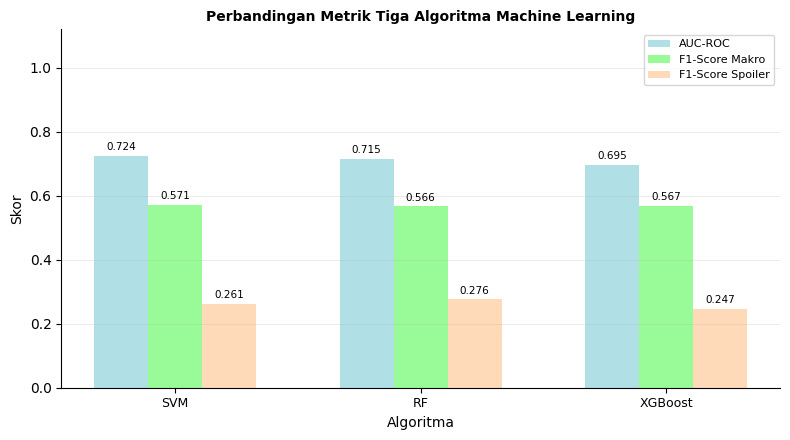

In [ ]:
model_names = list(results.keys())
auc_values = [results[m]["auc_roc"] for m in model_names]
f1_macro = [results[m]["f1_macro"] for m in model_names]
f1_spoiler = [results[m]["f1_1"] for m in model_names]

x = np.arange(len(model_names))
width = 0.22
C1, C2, C3 = "powderblue", "palegreen", "peachpuff"

fig, ax = plt.subplots(figsize=(8, 4.5))
bars1 = ax.bar(x - width, auc_values, width, label="AUC-ROC", color=C1)
bars2 = ax.bar(x, f1_macro, width, label="F1-Score Makro", color=C2)
bars3 = ax.bar(x + width, f1_spoiler, width, label="F1-Score Spoiler", color=C3)

ax.set_xlabel("Algoritma", fontsize=10)
ax.set_ylabel("Skor", fontsize=10)
ax.set_title("Perbandingan Metrik Tiga Algoritma Machine Learning", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis="y", alpha=0.25, linewidth=0.7)
ax.spines[["top","right"]].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012, f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig("ml_perbandingan_metrik.png", dpi=300, bbox_inches="tight")
plt.show()

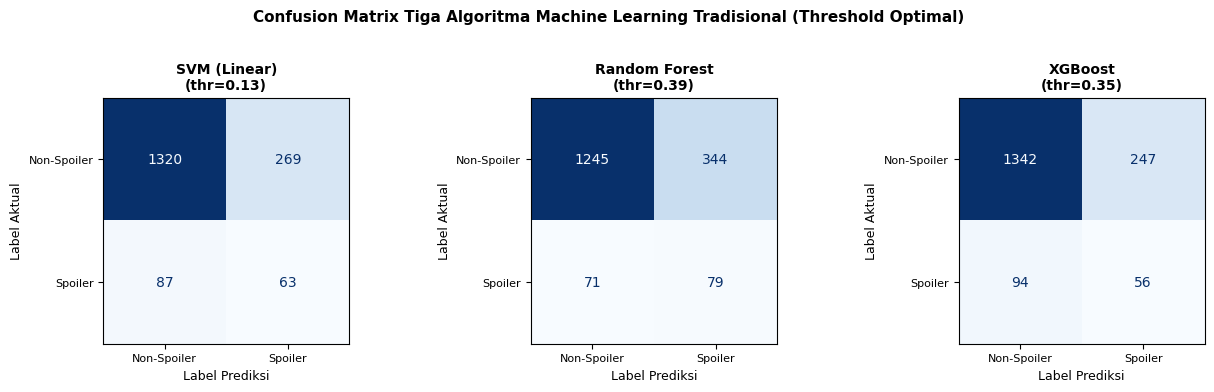

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

model_pred_pairs = [
    (f"SVM (Linear)\n(thr={svm_best_thr:.2f})",  predictions["SVM"]),
    (f"Random Forest\n(thr={rf_best_thr:.2f})",   predictions["RF"]),
    (f"XGBoost\n(thr={xgb_best_thr:.2f})",        predictions["XGBoost"]),
]

for ax, (name, pred) in zip(axes, model_pred_pairs):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Spoiler", "Spoiler"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Label Prediksi", fontsize=9)
    ax.set_ylabel("Label Aktual", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(
    "Confusion Matrix Tiga Algoritma Machine Learning Tradisional (Threshold Optimal)",
    fontsize=11, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("ml_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


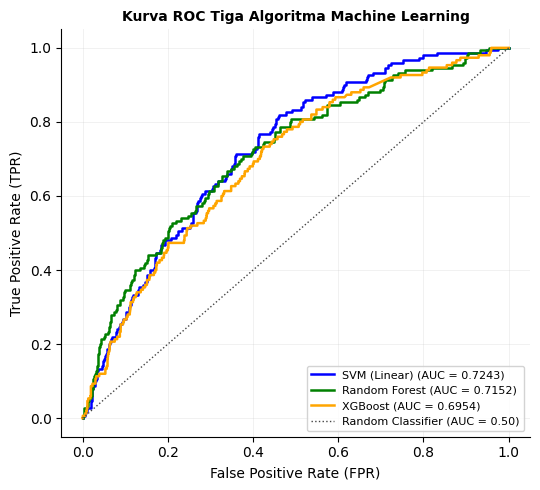

roc scores disimpan ke roc_scores_ml.pkl untuk digabung dengan roc dl nanti


In [ ]:
# roc curve tiga algoritma ml
from sklearn.metrics import roc_curve

all_scores = {
    "SVM (Linear)": svm_score,   # probabilitas dari CalibratedClassifierCV
    "Random Forest": rf_score,
    "XGBoost": xgb_score,
}

COLORS_ROC = ["blue", "green", "orange"]
STYLES = ["-", "-", "-"]

fig, ax = plt.subplots(figsize=(5.5, 5))
for (name, score), color, ls in zip(all_scores.items(), COLORS_ROC, STYLES):
    fpr, tpr, _ = roc_curve(y_test, score)
    auc_val = roc_auc_score(y_test, score)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=color, lw=1.8, ls=ls)

ax.plot([0,1],[0,1], color="#444444", lw=1, ls=":", label="Random Classifier (AUC = 0.50)")
ax.set_xlabel("False Positive Rate (FPR)", fontsize=10)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=10)
ax.set_title("Kurva ROC Tiga Algoritma Machine Learning", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.85)
ax.grid(alpha=0.2, linewidth=0.6)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("ml_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# simpan skor untuk roc curve gabungan di notebook bert
import pickle
roc_scores_ml = {
    "SVM (Linear)"  : svm_score.tolist(),
    "Random Forest" : rf_score.tolist(),
    "XGBoost"       : xgb_score.tolist(),
    "y_test"        : y_test.tolist()
}
with open("roc_scores_ml.pkl", "wb") as f:
    pickle.dump(roc_scores_ml, f)
print("roc scores disimpan ke roc_scores_ml.pkl untuk digabung dengan roc dl nanti")


## 10. Ringkasan Hasil

In [ ]:
# model terbaik untuk setiap metrik
best_auc_model = max(results, key=lambda m: results[m]["auc_roc"])
best_f1_model  = max(results, key=lambda m: results[m]["f1_1"])
best_rec_model = max(results, key=lambda m: results[m]["recall_1"])

print("RINGKASAN HASIL ALGORITMA MACHINE LEARNING")
print(f"\nAlgoritma terbaik berdasarkan AUC-ROC   : {best_auc_model} ({results[best_auc_model]['auc_roc']:.4f})")
print(f"Algoritma terbaik berdasarkan F1 spoiler : {best_f1_model} ({results[best_f1_model]['f1_1']:.4f})")
print(f"Algoritma terbaik berdasarkan recall spoiler: {best_rec_model} ({results[best_rec_model]['recall_1']:.4f})")

threshold_map = {
    "SVM"     : svm_best_thr,
    "RF"      : rf_best_thr,
    "XGBoost" : xgb_best_thr,
}

print("\nPerbandingan Final (threshold optimal)")
for model, r in results.items():
    thr = threshold_map.get(model, 0.50)
    print(f"\n{model} (threshold={thr:.4f}):")
    print(f"AUC-ROC: {r['auc_roc']:.4f}")
    print(f"F1 spoiler: {r['f1_1']:.4f}")
    print(f"Recall spoiler: {r['recall_1']:.4f}")
    print(f"F1 macro: {r['f1_macro']:.4f}")


RINGKASAN HASIL ALGORITMA MACHINE LEARNING

Algoritma terbaik berdasarkan AUC-ROC   : SVM (0.7243)
Algoritma terbaik berdasarkan F1 spoiler : RF (0.2757)
Algoritma terbaik berdasarkan recall spoiler: RF (0.5267)

Perbandingan Final (threshold optimal)

SVM (threshold=0.1269):
AUC-ROC: 0.7243
F1 spoiler: 0.2614
Recall spoiler: 0.4200
F1 macro: 0.5713

RF (threshold=0.3916):
AUC-ROC: 0.7152
F1 spoiler: 0.2757
Recall spoiler: 0.5267
F1 macro: 0.5664

XGBoost (threshold=0.3480):
AUC-ROC: 0.6954
F1 spoiler: 0.2472
Recall spoiler: 0.3733
F1 macro: 0.5673


In [ ]:
import os
import pickle

# folder output (pakai 1 folder utama kamu)
FIGURES_PATH = "/content/drive/MyDrive/NLP_Kelompok3/paper_figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

# pastikan variabel ini SUDAH ADA dari hasil training:
# svm_score, rf_score, xgb_score, y_test

roc_scores_ml = {
    "SVM (Linear)": svm_score.tolist(),
    "Random Forest": rf_score.tolist(),
    "XGBoost": xgb_score.tolist(),
    "y_test": y_test.tolist()
}

with open(os.path.join(FIGURES_PATH, "roc_scores_ml.pkl"), "wb") as f:
    pickle.dump(roc_scores_ml, f)

print("✓ roc_scores_ml.pkl berhasil disimpan")
print("jumlah data test:", len(y_test))

✓ roc_scores_ml.pkl berhasil disimpan
jumlah data test: 1739


In [ ]:
with open(os.path.join(FIGURES_PATH, "roc_scores_ml.pkl"), "rb") as f:
    roc_ml = pickle.load(f)

for k, v in roc_ml.items():
    print(k, len(v))

SVM (Linear) 1739
Random Forest 1739
XGBoost 1739
y_test 1739


Catatan Perubahan

**Mengapa Pipeline menggantikan TF-IDF standalone**  
TF-IDF yang di-fit di luar GridSearchCV menyebabkan data leakage: vocabulary terbentuk dari seluruh data latih sebelum cross-validation dimulai, sehingga setiap fold validasi sudah "terpengaruh" oleh distribusi kata dari fold training lainnya. Dengan Pipeline, TF-IDF di-fit ulang hanya pada data training di setiap fold, membuat evaluasi cross-validation menjadi valid.

**Handling imbalance dengan `class_weight='balanced'` dan `scale_pos_weight`**  
Pendekatan ini dipilih karena bekerja langsung pada fungsi loss tanpa mengubah distribusi data. SMOTE tidak dipakai karena interpolasi di ruang TF-IDF sparse tidak menghasilkan representasi teks yang bermakna secara linguistik. `scale_pos_weight` pada XGBoost sekarang ikut di-tune karena nilai optimal tidak selalu persis sama dengan rasio imbalance data.

**Keterbatasan**  
Model berbasis TF-IDF tidak memahami urutan kata. Kosakata yang sangat mirip antar kelas menjadi pembatas fundamental untuk semua model ML klasik, dan ini yang membuka motivasi untuk pendekatan deep learning dan BERT.

In [ ]:

import os, joblib, json

EXPORT_DIR = "/content/drive/MyDrive/NLP_Kelompok3/models_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

joblib.dump(best_svm, os.path.join(EXPORT_DIR, "svm_model.pkl"))
print("✓ svm_model.pkl")

joblib.dump(best_rf,  os.path.join(EXPORT_DIR, "rf_model.pkl"))
print("✓ rf_model.pkl")

joblib.dump(best_xgb, os.path.join(EXPORT_DIR, "xgb_model.pkl"))
print("✓ xgb_model.pkl")

# simpan metrik ML ke dict sementara
ml_metrics = {}
for model_name, r in results.items():
    ml_metrics[model_name] = {
        "auc_roc"    : round(r["auc_roc"],     4),
        "f1_1"       : round(r["f1_1"],        4),
        "f1_0"       : round(r["f1_0"],        4),
        "f1_macro"   : round(r["f1_macro"],    4),
        "recall_1"   : round(r["recall_1"],    4),
        "recall_0"   : round(r["recall_0"],    4),
        "precision_1": round(r["precision_1"], 4),
        "precision_0": round(r["precision_0"], 4),
    }

# simpan sementara ke Drive
with open(os.path.join(EXPORT_DIR, "_ml_metrics_tmp.json"), "w") as f:
    json.dump(ml_metrics, f)
print("✓ _ml_metrics_tmp.json (sementara)")

✓ svm_model.pkl
✓ rf_model.pkl
✓ xgb_model.pkl
✓ _ml_metrics_tmp.json (sementara)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, json

EXPORT_DIR = "/content/drive/MyDrive/NLP_Kelompok3/models_export"

all_metrics = {}

for tmp_file in ["_ml_metrics_tmp.json", "_lstm_metrics_tmp.json", "_bert_metrics_tmp.json"]:
    path = os.path.join(EXPORT_DIR, tmp_file)
    if os.path.exists(path):
        with open(path) as f:
            all_metrics.update(json.load(f))
        print(f"✓ dimuat: {tmp_file}")
    else:
        print(f"⚠ tidak ditemukan: {tmp_file} — skip")

final = {"models": all_metrics}
with open(os.path.join(EXPORT_DIR, "metrics.json"), "w") as f:
    json.dump(final, f, indent=2)

print("\n✓ metrics.json berhasil dibuat!")
print(f"Model yang tercakup: {list(all_metrics.keys())}")
print("\nLangkah selanjutnya:")
print("1. Download folder models_export dari Google Drive")
print("2. Rename jadi 'models'")
print("3. Letakkan di dalam folder spoiler_detector/")
print("4. Jalankan: python3 app.py")

✓ dimuat: _ml_metrics_tmp.json
✓ dimuat: _lstm_metrics_tmp.json
⚠ tidak ditemukan: _bert_metrics_tmp.json — skip

✓ metrics.json berhasil dibuat!
Model yang tercakup: ['SVM', 'RF', 'XGBoost', 'BiLSTM']

Langkah selanjutnya:
1. Download folder models_export dari Google Drive
2. Rename jadi 'models'
3. Letakkan di dalam folder spoiler_detector/
4. Jalankan: python3 app.py
